In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
weight = 0.3
bias = 0.9

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.9000],
         [0.9060],
         [0.9120],
         [0.9180],
         [0.9240],
         [0.9300],
         [0.9360],
         [0.9420],
         [0.9480],
         [0.9540]]))

In [4]:
training_split = int(0.8 * len(X))

X_train, y_train = X[:training_split], y[:training_split]
X_test, y_test = X[training_split:], y[training_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  plt.figure(figsize=(10, 7))
  plt.grid(True)
  plt.xlabel("X")
  plt.ylabel("y")

  plt.plot(train_data, train_labels, label="Training Data")
  plt.plot(test_data, test_labels, label="Test Data")

  if predictions is not None:
    plt.scatter(test_data, predictions, label="Predictions", c="r")

  plt.legend(prop={"size": 14})

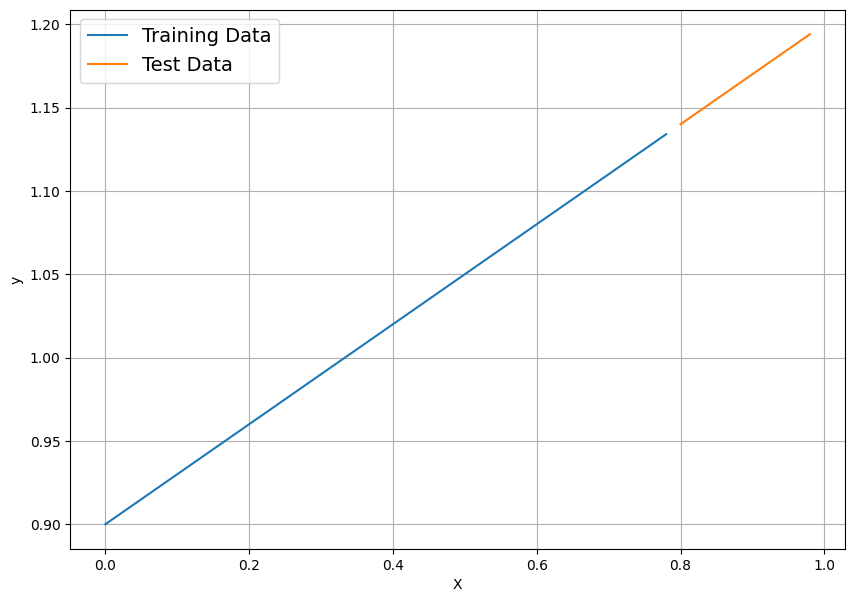

In [6]:
plot_predictions(X_train, y_train, X_test, y_test)

In [7]:
class RegresionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)

model_0 = RegresionModel()
model_0, model_0.state_dict()

(RegresionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [8]:
next(model_0.parameters()).device

device(type='cpu')

In [11]:
model_0.to(device)
next(model_0.parameters()).device

device(type='cuda', index=0)

In [13]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [19]:
torch.manual_seed(42)

epochs = 300

# Move data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  y_preds = model_0(X_train)

  loss = loss_fn(y_preds, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ## testing
  model_0.eval()

  with torch.inference_mode():
    test_preds = model_0(X_test)
    test_loss = loss_fn(test_preds, y_test)

  if epoch % 20 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 20 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 40 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 60 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 80 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 100 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 120 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 140 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 160 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 180 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 200 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 220 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 240 | Loss: 0.007012799382209778 | Test Loss: 0.003249275730922818
Epoch: 260 | Loss: 0.007012799382209778 | Te

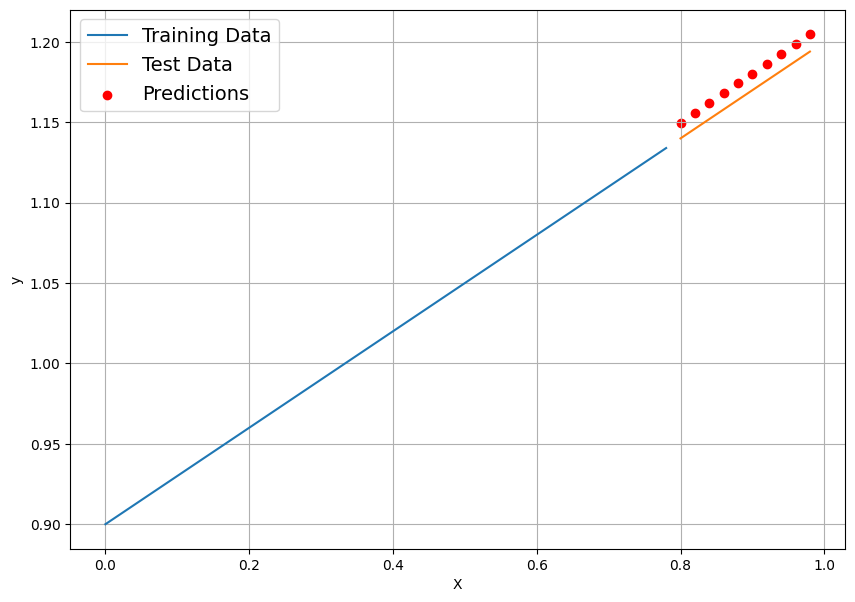

In [18]:
plot_predictions(predictions=test_preds.cpu())

In [20]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to models/01_pytorch_workflow.pth


In [21]:
loaded_model_0 = RegresionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_0.to(device)

RegresionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [24]:
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_0_preds = loaded_model_0(X_test)

y_preds == model_0(X_test)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')